<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/20B_NeuroFHIR_TRACE_Corrected_Three_State_Gate_Calibration_SELF_CONTAINED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 20B
## Corrected Three-State TRACE Gate Calibration

**Purpose:** Fix the threshold-collapse observed in Notebook 20 while preserving the frozen development/held-out evaluation design.

### Problem corrected

Notebook 20 produced:

- TRUSTED threshold ≈ REVIEW_REQUIRED threshold
- essentially no CAUTION region
- an unintended binary gate

That is inconsistent with the intended TRACE architecture:

**TRUSTED → CAUTION → REVIEW_REQUIRED**

### Notebook 20B goals

1. load Notebook 20's frozen evaluation table;
2. reuse the same development / held-out split;
3. refit the same FULL TRACE model on development data only;
4. calibrate **two distinct thresholds** with a required minimum CAUTION region;
5. freeze the three-state gate;
6. evaluate it once on held-out data;
7. verify risk monotonicity:

> observed instability(TRUSTED) < observed instability(CAUTION) < observed instability(REVIEW_REQUIRED)

8. compare corrected three-state routing with the original binary-like routing;
9. save a final gate configuration for Notebook 21.

### Important
If the notebook is running in DEMO_MODE, the results remain engineering/pipeline validation only.


In [1]:

# ============================================================
# 0. SETUP
# ============================================================

!pip -q install pandas numpy scipy scikit-learn pyarrow matplotlib

from pathlib import Path
import json, warnings, random
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/neurofhir_trace")
IN20 = ROOT / "outputs_20"
OUT_DIR = ROOT / "outputs_20B"
FIG_DIR = OUT_DIR / "figures"

for p in [OUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Input directory:", IN20)
print("Output directory:", OUT_DIR)


Input directory: /content/neurofhir_trace/outputs_20
Output directory: /content/neurofhir_trace/outputs_20B



# 1. Load Notebook 20 frozen evaluation table

Preferred source:

`trace20_frozen_evaluation_table.parquet`

This avoids redefining the evaluation sample after seeing held-out performance.


In [2]:

# ============================================================
# 1. LOAD FROZEN TABLE OR RECREATE DEMO TABLE
# ============================================================

candidate_paths = [
    IN20 / "trace20_frozen_evaluation_table.parquet",
    IN20 / "trace20_complete_evaluation_table.parquet",
    Path("/content/trace20_frozen_evaluation_table.parquet"),
    Path("/content/trace20_complete_evaluation_table.parquet"),
]

table_path = next((p for p in candidate_paths if p.exists()), None)

if table_path is not None:
    eval_df = pd.read_parquet(table_path)
    DEMO_MODE = False

    print("Loaded frozen Notebook 20 table:", table_path)
    print("Rows:", len(eval_df))
    print("Subjects:", eval_df.subject_id.nunique())

else:
    # --------------------------------------------------------
    # SELF-CONTAINED FALLBACK
    # Recreates the same style of independent synthetic
    # evaluation table used by Notebook 20.
    # This is PIPELINE VALIDATION ONLY, not manuscript evidence.
    # --------------------------------------------------------
    print("Notebook 20 frozen table not found.")
    print("Recreating independent DEMO evaluation table.")
    print("IMPORTANT: Results remain pipeline-validation only.")

    DEMO_MODE = True

    rng = np.random.default_rng(SEED)

    n_subjects = 160
    subject_ids = [f"D{i:03d}" for i in range(1, n_subjects + 1)]

    shuffled = subject_ids.copy()
    rng.shuffle(shuffled)

    n_dev = int(0.70 * n_subjects)
    dev_ids = set(shuffled[:n_dev])

    rows = []

    for sid in subject_ids:
        split = "development" if sid in dev_ids else "heldout"

        # Independent latent technical instability.
        latent_unstable = rng.binomial(1, 0.38)

        # Four noisy TRACE signal families.
        variability_risk = np.clip(
            rng.normal(
                0.035 + 0.055 * latent_unstable,
                0.025
            ),
            0,
            0.25
        )

        domain_risk = np.clip(
            rng.normal(
                0.7 + 1.4 * latent_unstable,
                0.8
            ),
            0,
            5
        )

        provenance_risk = np.clip(
            rng.beta(
                1.2 + 2.5 * latent_unstable,
                8
            ),
            0,
            1
        )

        direction_stability = np.clip(
            rng.normal(
                0.88 - 0.38 * latent_unstable,
                0.18
            ),
            0,
            1
        )

        longitudinal_risk = 1.0 - direction_stability

        # Independent downstream false-change event.
        false_change_probability = np.clip(
            0.08
            + 0.50 * latent_unstable
            + 0.15 * longitudinal_risk,
            0,
            0.95
        )

        false_change_event = rng.binomial(
            1,
            false_change_probability
        )

        rows.append({
            "subject_id": sid,
            "visit_id": "M12",
            "split": split,
            "variability_risk": variability_risk,
            "domain_risk": domain_risk,
            "provenance_risk": provenance_risk,
            "longitudinal_risk": longitudinal_risk,
            "unstable_reference": latent_unstable,
            "false_change_event": false_change_event,
            "reference_source": "synthetic_latent_independent"
        })

    eval_df = pd.DataFrame(rows)

    print("\nRecreated DEMO table:")
    print("Rows:", len(eval_df))
    print("Subjects:", eval_df.subject_id.nunique())
    print(eval_df["split"].value_counts())

# Save local copy for reproducibility within this runtime.
eval_df.to_parquet(
    OUT_DIR / "trace20B_input_evaluation_table.parquet",
    index=False
)

print("\nDEMO_MODE =", DEMO_MODE)


Notebook 20 frozen table not found.
Recreating independent DEMO evaluation table.
IMPORTANT: Results remain pipeline-validation only.

Recreated DEMO table:
Rows: 160
Subjects: 160
split
development    112
heldout         48
Name: count, dtype: int64

DEMO_MODE = True



# 2. Confirm evaluation contract


In [3]:

# ============================================================
# 2. INPUT VALIDATION
# ============================================================

FEATURES = [
    "variability_risk",
    "domain_risk",
    "provenance_risk",
    "longitudinal_risk"
]

required = [
    "subject_id",
    "split",
    "unstable_reference"
] + FEATURES

missing = [c for c in required if c not in eval_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

dev = eval_df[eval_df.split=="development"].copy()
held = eval_df[eval_df.split=="heldout"].copy()

print("Development rows:", len(dev))
print("Held-out rows:", len(held))
print("Development unstable prevalence:", round(dev.unstable_reference.mean(),3))
print("Held-out unstable prevalence:", round(held.unstable_reference.mean(),3))


Development rows: 112
Held-out rows: 48
Development unstable prevalence: 0.384
Held-out unstable prevalence: 0.438



# 3. Refit FULL TRACE on development data only

Notebook 20B uses the same transparent logistic model:

- variability risk
- domain risk
- provenance risk
- longitudinal risk


In [4]:

# ============================================================
# 3. FULL TRACE DEVELOPMENT MODEL
# ============================================================

trace_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        random_state=SEED
    ))
])

trace_model.fit(
    dev[FEATURES],
    dev["unstable_reference"]
)

dev["trace_risk"] = trace_model.predict_proba(
    dev[FEATURES]
)[:,1]

held["trace_risk"] = trace_model.predict_proba(
    held[FEATURES]
)[:,1]

coef = trace_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": FEATURES,
    "standardized_log_odds_coefficient": coef,
    "odds_ratio_per_1SD": np.exp(coef)
}).sort_values(
    "standardized_log_odds_coefficient",
    ascending=False
)

display(coef_df)


,feature,standardized_log_odds_coefficient,odds_ratio_per_1SD
0,variability_risk,1.998247,7.376115
3,longitudinal_risk,1.425434,4.159661
1,domain_risk,1.376566,3.961276
2,provenance_risk,0.974570,2.650028



# 4. Corrected three-state calibration strategy

Instead of choosing thresholds independently and allowing them to collide, this notebook searches **threshold pairs jointly**.

A candidate pair must satisfy:

### Structural constraints
- `trusted_threshold < review_threshold`
- CAUTION must cover at least a minimum proportion of development evidence
- TRUSTED and REVIEW_REQUIRED must each contain a minimum proportion

### Safety / performance constraints
- TRUSTED group should have high NPV
- REVIEW_REQUIRED group should have high sensitivity for unstable evidence
- observed instability should increase monotonically across states

### Optimization
Among valid threshold pairs, choose the pair that balances:
- high REVIEW sensitivity
- high TRUSTED NPV
- useful CAUTION coverage
- monotonic separation across the three states


In [5]:

# ============================================================
# 4. JOINT THREE-STATE THRESHOLD SEARCH
# ============================================================

MIN_TRUSTED_FRAC = 0.15
MIN_CAUTION_FRAC = 0.15
MIN_REVIEW_FRAC = 0.15

TARGET_TRUSTED_NPV = 0.90
TARGET_REVIEW_SENS = 0.80

def assign_state(p, t_trusted, t_review):
    p = np.asarray(p)

    out = np.full(
        len(p),
        "CAUTION",
        dtype=object
    )

    out[p <= t_trusted] = "TRUSTED"
    out[p >= t_review] = "REVIEW_REQUIRED"

    return out


def state_stats(y, p, t_trusted, t_review):
    states = assign_state(p, t_trusted, t_review)

    df = pd.DataFrame({
        "y": np.asarray(y).astype(int),
        "p": np.asarray(p),
        "state": states
    })

    stats_out = {}

    for state in [
        "TRUSTED",
        "CAUTION",
        "REVIEW_REQUIRED"
    ]:
        g = df[df.state==state]

        stats_out[f"{state}_n"] = len(g)
        stats_out[f"{state}_frac"] = len(g)/len(df) if len(df) else np.nan
        stats_out[f"{state}_observed_instability"] = (
            g.y.mean() if len(g) else np.nan
        )

    # NPV among TRUSTED
    trusted = df[df.state=="TRUSTED"]
    trusted_npv = (
        np.mean(trusted.y==0)
        if len(trusted) else np.nan
    )

    # Sensitivity of REVIEW_REQUIRED for unstable cases.
    total_unstable = int((df.y==1).sum())
    review_captured = int(
        ((df.y==1) & (df.state=="REVIEW_REQUIRED")).sum()
    )

    review_sensitivity = (
        review_captured/total_unstable
        if total_unstable else np.nan
    )

    stats_out["trusted_npv"] = trusted_npv
    stats_out["review_sensitivity"] = review_sensitivity

    return stats_out


def monotonic_instability(stats_dict):
    a = stats_dict["TRUSTED_observed_instability"]
    b = stats_dict["CAUTION_observed_instability"]
    c = stats_dict["REVIEW_REQUIRED_observed_instability"]

    if any(pd.isna(x) for x in [a,b,c]):
        return False

    return a <= b <= c


y_dev = dev["unstable_reference"].values
p_dev = dev["trace_risk"].values

# Quantile-derived candidate thresholds avoid overfitting to every unique probability.
quantiles = np.linspace(0.05, 0.95, 37)
candidates = np.unique(
    np.quantile(p_dev, quantiles)
)

search_rows = []

for t_trusted in candidates:
    for t_review in candidates:

        if t_trusted >= t_review:
            continue

        s = state_stats(
            y_dev,
            p_dev,
            t_trusted,
            t_review
        )

        if s["TRUSTED_frac"] < MIN_TRUSTED_FRAC:
            continue
        if s["CAUTION_frac"] < MIN_CAUTION_FRAC:
            continue
        if s["REVIEW_REQUIRED_frac"] < MIN_REVIEW_FRAC:
            continue

        if pd.isna(s["trusted_npv"]) or pd.isna(s["review_sensitivity"]):
            continue

        if s["trusted_npv"] < TARGET_TRUSTED_NPV:
            continue

        if s["review_sensitivity"] < TARGET_REVIEW_SENS:
            continue

        if not monotonic_instability(s):
            continue

        # Reward separation between states.
        sep1 = (
            s["CAUTION_observed_instability"] -
            s["TRUSTED_observed_instability"]
        )
        sep2 = (
            s["REVIEW_REQUIRED_observed_instability"] -
            s["CAUTION_observed_instability"]
        )

        # Joint objective.
        score = (
            2.0*s["trusted_npv"] +
            2.0*s["review_sensitivity"] +
            0.8*s["CAUTION_frac"] +
            1.2*sep1 +
            1.2*sep2
        )

        search_rows.append({
            "trusted_threshold": float(t_trusted),
            "review_threshold": float(t_review),
            "objective": score,
            **s
        })

search_df = pd.DataFrame(search_rows)

if len(search_df)==0:
    raise RuntimeError(
        "No valid three-state thresholds were found with the current constraints. "
        "Do not collapse the gate to binary. Relax constraints explicitly and rerun."
    )

search_df = search_df.sort_values(
    "objective",
    ascending=False
).reset_index(drop=True)

best = search_df.iloc[0]

trusted_threshold = float(best["trusted_threshold"])
review_threshold = float(best["review_threshold"])

print("Selected TRUSTED threshold:", trusted_threshold)
print("Selected REVIEW threshold:", review_threshold)
print("Threshold gap:", review_threshold-trusted_threshold)

display(
    search_df.head(10)[
        [
            "trusted_threshold",
            "review_threshold",
            "objective",
            "trusted_npv",
            "review_sensitivity",
            "TRUSTED_frac",
            "CAUTION_frac",
            "REVIEW_REQUIRED_frac",
            "TRUSTED_observed_instability",
            "CAUTION_observed_instability",
            "REVIEW_REQUIRED_observed_instability"
        ]
    ]
)


Selected TRUSTED threshold: 0.0041754254421767
Selected REVIEW threshold: 0.6709067530196758
Threshold gap: 0.6667313275774991


,trusted_threshold,review_threshold,objective,trusted_npv,review_sensitivity,TRUSTED_frac,CAUTION_frac,REVIEW_REQUIRED_frac,TRUSTED_observed_instability,CAUTION_observed_instability,REVIEW_REQUIRED_observed_instability
0,0.004175,0.670907,5.532060,1.0,0.976744,0.151786,0.473214,0.375000,0.0,0.018868,1.000000
1,0.006583,0.670907,5.510631,1.0,0.976744,0.178571,0.446429,0.375000,0.0,0.020000,1.000000
2,0.004175,0.373934,5.503810,1.0,1.000000,0.151786,0.446429,0.401786,0.0,0.000000,0.955556
3,0.008390,0.670907,5.489203,1.0,0.976744,0.205357,0.419643,0.375000,0.0,0.021277,1.000000
4,0.006583,0.373934,5.482381,1.0,1.000000,0.178571,0.419643,0.401786,0.0,0.000000,0.955556
5,0.009231,0.670907,5.474917,1.0,0.976744,0.223214,0.401786,0.375000,0.0,0.022222,1.000000
6,0.008390,0.373934,5.460952,1.0,1.000000,0.205357,0.392857,0.401786,0.0,0.000000,0.955556
7,0.011777,0.670907,5.453488,1.0,0.976744,0.250000,0.375000,0.375000,0.0,0.023810,1.000000
8,0.009231,0.373934,5.446667,1.0,1.000000,0.223214,0.375000,0.401786,0.0,0.000000,0.955556
9,0.013605,0.670907,5.432060,1.0,0.976744,0.276786,0.348214,0.375000,0.0,0.025641,1.000000



# 5. Freeze corrected gate before held-out analysis


In [6]:

# ============================================================
# 5. FREEZE CORRECTED GATE
# ============================================================

gate_config = {
    "trace_version": "20B",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "development_only_calibration": True,
    "features": FEATURES,
    "trusted_probability_max": trusted_threshold,
    "review_probability_min": review_threshold,
    "minimum_trusted_fraction_dev": MIN_TRUSTED_FRAC,
    "minimum_caution_fraction_dev": MIN_CAUTION_FRAC,
    "minimum_review_fraction_dev": MIN_REVIEW_FRAC,
    "target_trusted_npv_dev": TARGET_TRUSTED_NPV,
    "target_review_sensitivity_dev": TARGET_REVIEW_SENS
}

with open(
    OUT_DIR/"frozen_trace_three_state_gate.json",
    "w"
) as f:
    json.dump(gate_config,f,indent=2)

print(json.dumps(gate_config,indent=2))


{
  "trace_version": "20B",
  "created_utc": "2026-09-11T21:45:06.632471+00:00",
  "development_only_calibration": true,
  "features": [
    "variability_risk",
    "domain_risk",
    "provenance_risk",
    "longitudinal_risk"
  ],
  "trusted_probability_max": 0.0041754254421767,
  "review_probability_min": 0.6709067530196758,
  "minimum_trusted_fraction_dev": 0.15,
  "minimum_caution_fraction_dev": 0.15,
  "minimum_review_fraction_dev": 0.15,
  "target_trusted_npv_dev": 0.9,
  "target_review_sensitivity_dev": 0.8
}



# 6. Development-state diagnostics

Before touching held-out labels, verify that the calibration created a genuine three-state gate.


In [7]:

# ============================================================
# 6. DEVELOPMENT DIAGNOSTICS
# ============================================================

dev["trace_state"] = assign_state(
    dev["trace_risk"].values,
    trusted_threshold,
    review_threshold
)

dev_state_summary = (
    dev.groupby("trace_state", as_index=False)
    .agg(
        n=("unstable_reference","size"),
        observed_instability=("unstable_reference","mean"),
        mean_trace_risk=("trace_risk","mean")
    )
)

dev_state_summary["fraction"] = (
    dev_state_summary["n"]/len(dev)
)

state_order = [
    "TRUSTED",
    "CAUTION",
    "REVIEW_REQUIRED"
]

dev_state_summary["trace_state"] = pd.Categorical(
    dev_state_summary["trace_state"],
    categories=state_order,
    ordered=True
)

dev_state_summary = dev_state_summary.sort_values(
    "trace_state"
)

display(dev_state_summary)


,trace_state,n,observed_instability,mean_trace_risk,fraction
2,TRUSTED,17,0.000000,0.001545,0.151786
0,CAUTION,53,0.018868,0.087375,0.473214
1,REVIEW_REQUIRED,42,1.000000,0.965005,0.375000


In [8]:

# Hard structural checks.
dev_lookup = dev_state_summary.set_index(
    "trace_state"
)

assert set(state_order).issubset(
    set(dev["trace_state"].unique())
), "All three TRACE states must be present in development calibration."

dev_rates = [
    float(dev_lookup.loc[s,"observed_instability"])
    for s in state_order
]

assert dev_rates[0] <= dev_rates[1] <= dev_rates[2], (
    "Development instability is not monotonic across TRACE states."
)

assert (review_threshold-trusted_threshold) > 1e-4, (
    "Threshold gap is too small; gate is collapsing toward binary."
)

print("PASS: genuine three-state development gate.")
print("Development instability rates:", dev_rates)


PASS: genuine three-state development gate.
Development instability rates: [0.0, 0.018867924528301886, 1.0]



# 7. Held-out evaluation

The gate is now frozen.  
From this point onward, held-out labels are used only for evaluation.


In [9]:

# ============================================================
# 7. APPLY FROZEN GATE TO HELD-OUT DATA
# ============================================================

held["trace_state"] = assign_state(
    held["trace_risk"].values,
    trusted_threshold,
    review_threshold
)

held["trace_reliability_score"] = (
    1-held["trace_risk"]
)

held_state_summary = (
    held.groupby("trace_state", as_index=False)
    .agg(
        n=("unstable_reference","size"),
        observed_instability=("unstable_reference","mean"),
        mean_trace_risk=("trace_risk","mean")
    )
)

held_state_summary["fraction"] = (
    held_state_summary["n"]/len(held)
)

held_state_summary["trace_state"] = pd.Categorical(
    held_state_summary["trace_state"],
    categories=state_order,
    ordered=True
)

held_state_summary = held_state_summary.sort_values(
    "trace_state"
)

display(held_state_summary)


,trace_state,n,observed_instability,mean_trace_risk,fraction
2,TRUSTED,10,0.000000,0.001717,0.208333
0,CAUTION,18,0.055556,0.061721,0.375000
1,REVIEW_REQUIRED,20,1.000000,0.957393,0.416667



# 8. Held-out monotonicity check

A three-state gate is most interpretable when actual held-out instability also increases from TRUSTED to CAUTION to REVIEW_REQUIRED.

Because held-out sample sizes may be small, the notebook reports both strict and tolerant monotonicity.


In [10]:

# ============================================================
# 8. HELD-OUT MONOTONICITY
# ============================================================

held_lookup = held_state_summary.set_index(
    "trace_state"
)

present = [
    s for s in state_order
    if s in held_lookup.index
]

held_rates = {
    s: float(held_lookup.loc[s,"observed_instability"])
    for s in present
}

print("Held-out observed instability rates:")
print(held_rates)

strict_monotonic = True

if all(s in held_rates for s in state_order):
    strict_monotonic = (
        held_rates["TRUSTED"] <=
        held_rates["CAUTION"] <=
        held_rates["REVIEW_REQUIRED"]
    )

print("Strict monotonicity:", strict_monotonic)

if not strict_monotonic:
    print(
        "NOTE: Held-out monotonicity is imperfect. "
        "Do not retune thresholds on held-out data. "
        "Report this transparently and rely on confidence intervals / larger real validation."
    )


Held-out observed instability rates:
{'TRUSTED': 0.0, 'CAUTION': 0.05555555555555555, 'REVIEW_REQUIRED': 1.0}
Strict monotonicity: True



# 9. Discrimination and calibration metrics


In [11]:

# ============================================================
# 9. FULL TRACE METRICS
# ============================================================

y = held["unstable_reference"].values
p = held["trace_risk"].values

auroc = (
    roc_auc_score(y,p)
    if len(np.unique(y))==2
    else np.nan
)

auprc = (
    average_precision_score(y,p)
    if len(np.unique(y))==2
    else np.nan
)

brier = brier_score_loss(y,p)

review_mask = held["trace_state"].eq(
    "REVIEW_REQUIRED"
)
trusted_mask = held["trace_state"].eq(
    "TRUSTED"
)
caution_mask = held["trace_state"].eq(
    "CAUTION"
)

total_unstable = int((y==1).sum())
review_captured = int(
    ((y==1) & review_mask.values).sum()
)

review_sensitivity = (
    review_captured/total_unstable
    if total_unstable else np.nan
)

trusted_npv = (
    float(
        np.mean(
            held.loc[trusted_mask,"unstable_reference"]==0
        )
    )
    if trusted_mask.any()
    else np.nan
)

metrics = pd.DataFrame([{
    "AUROC": auroc,
    "AUPRC": auprc,
    "Brier": brier,
    "trusted_npv": trusted_npv,
    "review_sensitivity": review_sensitivity,
    "trusted_rate": trusted_mask.mean(),
    "caution_rate": caution_mask.mean(),
    "review_rate": review_mask.mean()
}])

display(metrics.T)


,0
AUROC,0.996473
AUPRC,0.995859
Brier,0.025065
trusted_npv,1.000000
review_sensitivity,0.952381
trusted_rate,0.208333
caution_rate,0.375000
review_rate,0.416667



# 10. State-specific instability table

This table is directly useful for the ICHI Results section.

The ideal pattern is:

| State | Observed instability |
|---|---|
| TRUSTED | lowest |
| CAUTION | intermediate |
| REVIEW_REQUIRED | highest |


In [12]:

state_table = held_state_summary[
    [
        "trace_state",
        "n",
        "fraction",
        "mean_trace_risk",
        "observed_instability"
    ]
].copy()

display(state_table)

state_table.to_csv(
    OUT_DIR/"heldout_three_state_instability.csv",
    index=False
)


,trace_state,n,fraction,mean_trace_risk,observed_instability
2,TRUSTED,10,0.208333,0.001717,0.000000
0,CAUTION,18,0.375000,0.061721,0.055556
1,REVIEW_REQUIRED,20,0.416667,0.957393,1.000000



# 11. False-change routing

If Notebook 20's frozen table contains `false_change_event`, measure whether review routing captures a disproportionate share of false-change events.


In [13]:

# ============================================================
# 11. FALSE-CHANGE ANALYSIS
# ============================================================

false_change_metrics = {}

if (
    "false_change_event" in held.columns and
    held["false_change_event"].notna().any()
):
    fc = held["false_change_event"].fillna(0).astype(int)

    total_fc = int(fc.sum())
    caught_review = int(
        (
            fc.eq(1) &
            held.trace_state.eq("REVIEW_REQUIRED")
        ).sum()
    )

    review_capture = (
        caught_review/total_fc
        if total_fc else np.nan
    )

    raw_rate = float(fc.mean())

    propagated = held.trace_state.ne(
        "REVIEW_REQUIRED"
    )

    propagated_rate = (
        float(fc[propagated].mean())
        if propagated.any()
        else np.nan
    )

    trusted_only_rate = (
        float(fc[held.trace_state.eq("TRUSTED")].mean())
        if held.trace_state.eq("TRUSTED").any()
        else np.nan
    )

    false_change_metrics = {
        "false_change_capture_by_review": review_capture,
        "raw_false_change_rate": raw_rate,
        "propagated_false_change_rate": propagated_rate,
        "trusted_only_false_change_rate": trusted_only_rate
    }

    display(
        pd.DataFrame(
            list(false_change_metrics.items()),
            columns=["metric","value"]
        )
    )
else:
    print("No false_change_event column available.")


,metric,value
0,false_change_capture_by_review,0.714286
1,raw_false_change_rate,0.437500
2,propagated_false_change_rate,0.214286
3,trusted_only_false_change_rate,0.300000



# 12. Three-state calibration figure


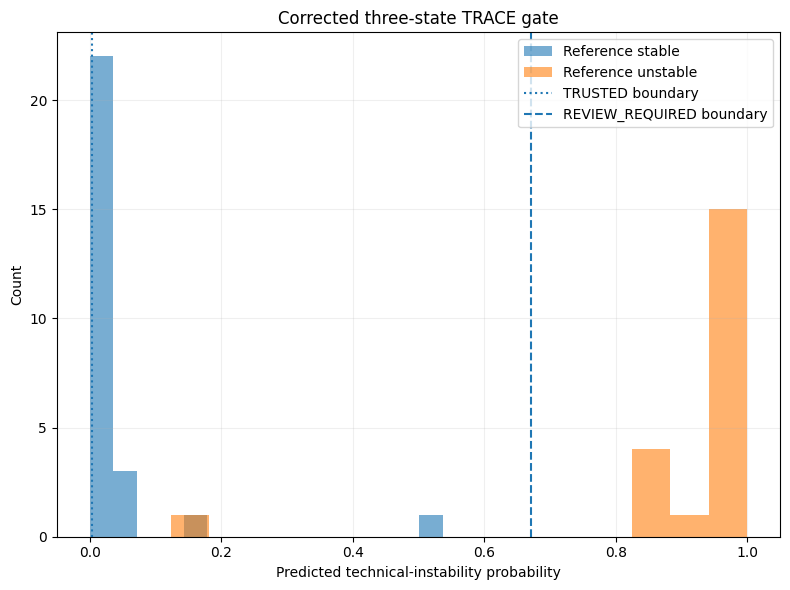

In [14]:

# ============================================================
# 12. RISK DISTRIBUTION + THRESHOLDS
# ============================================================

fig, ax = plt.subplots(figsize=(8,6))

stable = held[
    held.unstable_reference==0
]["trace_risk"]

unstable = held[
    held.unstable_reference==1
]["trace_risk"]

ax.hist(
    stable,
    bins=15,
    alpha=0.6,
    label="Reference stable"
)

ax.hist(
    unstable,
    bins=15,
    alpha=0.6,
    label="Reference unstable"
)

ax.axvline(
    trusted_threshold,
    linestyle=":",
    label="TRUSTED boundary"
)

ax.axvline(
    review_threshold,
    linestyle="--",
    label="REVIEW_REQUIRED boundary"
)

ax.set_xlabel(
    "Predicted technical-instability probability"
)
ax.set_ylabel("Count")
ax.set_title(
    "Corrected three-state TRACE gate"
)
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"corrected_three_state_trace_gate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 13. State-risk figure


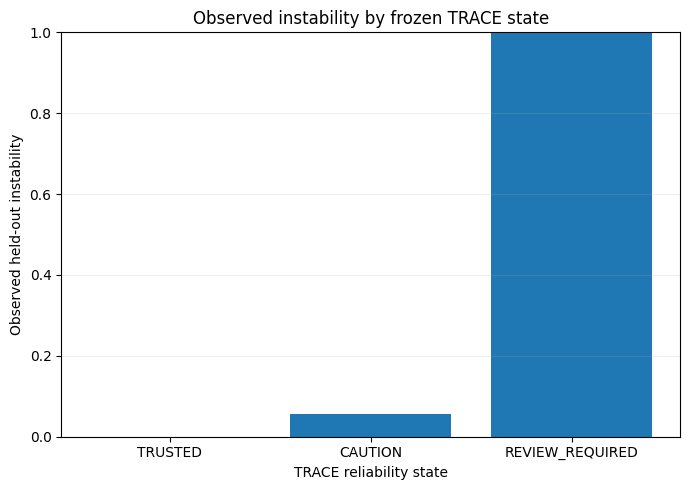

In [15]:

fig, ax = plt.subplots(figsize=(7,5))

plot_df = state_table.copy()

ax.bar(
    plot_df["trace_state"].astype(str),
    plot_df["observed_instability"]
)

ax.set_ylim(0,1)
ax.set_ylabel(
    "Observed held-out instability"
)
ax.set_xlabel(
    "TRACE reliability state"
)
ax.set_title(
    "Observed instability by frozen TRACE state"
)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"heldout_instability_by_trace_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 14. Optional subject-level bootstrap for state-risk separation

This estimates uncertainty in:

- TRUSTED instability rate;
- CAUTION instability rate;
- REVIEW_REQUIRED instability rate;
- difference REVIEW_REQUIRED − TRUSTED.


In [16]:

# ============================================================
# 14. SUBJECT BOOTSTRAP
# ============================================================

def bootstrap_state_rates(
    df,
    n_boot=500,
    seed=42
):
    rng = np.random.default_rng(seed)
    subjects = df.subject_id.unique()

    rows = []

    for b in range(n_boot):
        sampled = rng.choice(
            subjects,
            size=len(subjects),
            replace=True
        )

        pieces = []

        for i,sid in enumerate(sampled):
            x = df[df.subject_id==sid].copy()
            x["_boot_id"] = f"{sid}_{i}"
            pieces.append(x)

        boot = pd.concat(
            pieces,
            ignore_index=True
        )

        row = {"bootstrap": b}

        valid = True

        for state in state_order:
            g = boot[
                boot.trace_state==state
            ]

            if len(g)==0:
                valid = False
                break

            row[f"{state}_instability"] = (
                g.unstable_reference.mean()
            )

        if not valid:
            continue

        row["REVIEW_minus_TRUSTED"] = (
            row["REVIEW_REQUIRED_instability"] -
            row["TRUSTED_instability"]
        )

        row["CAUTION_minus_TRUSTED"] = (
            row["CAUTION_instability"] -
            row["TRUSTED_instability"]
        )

        rows.append(row)

    return pd.DataFrame(rows)


boot = bootstrap_state_rates(
    held,
    n_boot=500,
    seed=SEED
)

ci_rows = []

for col in boot.columns:
    if col=="bootstrap":
        continue

    s = boot[col].dropna()

    ci_rows.append({
        "metric": col,
        "mean": s.mean(),
        "ci_2.5": s.quantile(0.025),
        "ci_97.5": s.quantile(0.975)
    })

state_boot_ci = pd.DataFrame(ci_rows)

display(state_boot_ci)


,metric,mean,ci_2.5,ci_97.5
0,TRUSTED_instability,0.000000,0.0,0.0000
1,CAUTION_instability,0.056592,0.0,0.1875
2,REVIEW_REQUIRED_instability,1.000000,1.0,1.0000
3,REVIEW_minus_TRUSTED,1.000000,1.0,1.0000
4,CAUTION_minus_TRUSTED,0.056592,0.0,0.1875



# 15. Export corrected gate


In [17]:

# ============================================================
# 15. EXPORTS
# ============================================================

held_export_cols = [
    c for c in [
        "subject_id",
        "visit_id",
        "unstable_reference",
        "false_change_event",
        "trace_risk",
        "trace_reliability_score",
        "trace_state"
    ]
    if c in held.columns
]

held[
    held_export_cols
].to_csv(
    OUT_DIR/"heldout_three_state_trace_predictions.csv",
    index=False
)

dev_state_summary.to_csv(
    OUT_DIR/"development_three_state_summary.csv",
    index=False
)

held_state_summary.to_csv(
    OUT_DIR/"heldout_three_state_summary.csv",
    index=False
)

search_df.to_csv(
    OUT_DIR/"development_threshold_pair_search.csv",
    index=False
)

coef_df.to_csv(
    OUT_DIR/"trace20B_coefficients.csv",
    index=False
)

state_boot_ci.to_csv(
    OUT_DIR/"three_state_bootstrap_ci.csv",
    index=False
)

print("Saved corrected 20B artifacts to:", OUT_DIR)


Saved corrected 20B artifacts to: /content/neurofhir_trace/outputs_20B



# 16. Final ICHI decision summary


In [18]:

# ============================================================
# 16. SUMMARY
# ============================================================

summary = {
    "trusted_threshold": trusted_threshold,
    "review_threshold": review_threshold,
    "threshold_gap": review_threshold-trusted_threshold,
    "heldout_AUROC": auroc,
    "heldout_AUPRC": auprc,
    "heldout_Brier": brier,
    "trusted_rate": trusted_mask.mean(),
    "caution_rate": caution_mask.mean(),
    "review_rate": review_mask.mean(),
    "trusted_NPV": trusted_npv,
    "review_sensitivity": review_sensitivity,
    "heldout_strict_monotonicity": bool(strict_monotonic)
}

summary.update(false_change_metrics)

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["metric","value"]
)

display(summary_df)

summary_df.to_csv(
    OUT_DIR/"ichi_trace_20B_summary.csv",
    index=False
)


,metric,value
0,trusted_threshold,0.004175
1,review_threshold,0.670907
2,threshold_gap,0.666731
3,heldout_AUROC,0.996473
4,heldout_AUPRC,0.995859
5,heldout_Brier,0.025065
6,trusted_rate,0.208333
7,caution_rate,0.375
8,review_rate,0.416667
9,trusted_NPV,1.0



# 17. Interpretation rules

## PASS for Notebook 21 when:

1. all three states are non-empty;
2. CAUTION is meaningfully represented;
3. thresholds are clearly separated;
4. held-out instability generally increases from TRUSTED to REVIEW_REQUIRED;
5. TRUSTED evidence shows substantially lower instability than REVIEW_REQUIRED evidence;
6. REVIEW_REQUIRED captures a meaningful fraction of unstable/false-change cases;
7. review rate remains operationally plausible.

## Do not retune on held-out data

If held-out monotonicity is imperfect, do **not** change thresholds to make the plot look better.

Instead:

- report the held-out behavior honestly;
- use confidence intervals;
- increase real validation data if feasible;
- retain development-frozen thresholds.

That protects the scientific validity of the ICHI experiment.

---

# Next Notebook — 21

Once 20B passes, proceed to:

## Downstream Model A vs B vs C

- **A:** clinical baseline
- **B:** clinical + raw imaging AI
- **C1:** trusted-only imaging
- **C2:** reliability-weighted imaging
- **C3:** full TRACE-gated imaging

Notebook 21 should test whether reliability-aware handling improves:

- calibration;
- Brier score;
- ranking stability;
- false progression control;
- shift robustness;
- discrimination where applicable.

A higher AUROC is not required for the TRACE contribution to be successful.
